# 05 — Baselines univariados

Objetivo: estabelecer referências simples para a previsão do Diesel S10/RS uma semana à frente. As 26 semanas finais são avaliadas por walk-forward expansivo, sem embaralhamento e sem variáveis externas.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.baseline import (
    MODEL_COLUMNS, add_error_columns, evaluate_predictions,
    load_feature_dataset, save_baseline_results, walk_forward_baselines,
)

## 1. Carregar o Dataset V0

In [2]:
dataset_path = PROJECT_ROOT / 'final' / 'diesel_s10_rs_features_univariate_v0.csv'
data = load_feature_dataset(dataset_path)
display(data.groupby('conjunto', sort=False).agg(
    inicio=('semana_alvo', 'min'), fim=('semana_alvo', 'max'), linhas=('semana_alvo', 'size')
))

,inicio,fim,linhas
conjunto,,,
treino,2024-04-07,2025-12-28,91
teste,2026-01-04,2026-06-28,26


In [3]:
assert data['semana_alvo'].is_monotonic_increasing
assert data['conjunto'].eq('teste').sum() == 26
assert data.loc[data['conjunto'].eq('treino'), 'semana_alvo'].max() < data.loc[data['conjunto'].eq('teste'), 'semana_alvo'].min()
print('Divisão temporal válida.')

Divisão temporal válida.


## 2. Executar o walk-forward

Modelos comparados:

- **Naive:** previsão de `t+1` igual ao preço em `t`.
- **Média móvel:** média dos preços das quatro semanas conhecidas até `t`.
- **Regressão linear:** relação entre preço em `t` e `t+1`, reajustada após cada nova semana observada.

In [4]:
predictions = walk_forward_baselines(data)
predictions = add_error_columns(predictions)
display(predictions.head())
display(predictions.tail())

,semana_referencia,semana_alvo,preco_t,preco_real,direcao_real,pred_naive,pred_media_movel_4,pred_regressao_linear,regressao_intercepto,regressao_coeficiente,observacoes_treino,erro_naive,erro_abs_naive,erro_media_movel_4,erro_abs_media_movel_4,erro_regressao_linear,erro_abs_regressao_linear
0,2025-12-28,2026-01-04,6.161401,6.203864,1,6.161401,6.166643,6.163939,0.376550,0.939298,91,-0.042463,0.042463,-0.037220,0.037220,-0.039925,0.039925
1,2026-01-04,2026-01-11,6.203864,6.237414,1,6.203864,6.174034,6.204248,0.378898,0.938987,92,-0.033550,0.033550,-0.063379,0.063379,-0.033166,0.033166
2,2026-01-11,2026-01-18,6.237414,6.230837,0,6.237414,6.188343,6.236154,0.374786,0.939711,93,0.006577,0.006577,-0.042494,0.042494,0.005317,0.005317
3,2026-01-18,2026-01-25,6.230837,6.217886,0,6.230837,6.208379,6.229904,0.376199,0.939473,94,0.012951,0.012951,-0.009507,0.009507,0.012018,0.012018
4,2026-01-25,2026-02-01,6.217886,6.210664,0,6.217886,6.222500,6.217590,0.379016,0.938997,95,0.007222,0.007222,0.011836,0.011836,0.006926,0.006926


,semana_referencia,semana_alvo,preco_t,preco_real,direcao_real,pred_naive,pred_media_movel_4,pred_regressao_linear,regressao_intercepto,regressao_coeficiente,observacoes_treino,erro_naive,erro_abs_naive,erro_media_movel_4,erro_abs_media_movel_4,erro_regressao_linear,erro_abs_regressao_linear
21,2026-05-24,2026-05-31,7.004780,6.975223,0,7.004780,7.058367,7.002695,0.104012,0.984854,112,0.029557,0.029557,0.083144,0.083144,0.027472,0.027472
22,2026-05-31,2026-06-07,6.975223,6.955926,0,6.975223,7.027918,6.972235,0.113721,0.983268,113,0.019297,0.019297,0.071992,0.071992,0.016309,0.016309
23,2026-06-07,2026-06-14,6.955926,6.925493,0,6.955926,6.998878,6.952537,0.118994,0.982406,114,0.030433,0.030433,0.073385,0.073385,0.027044,0.027044
24,2026-06-14,2026-06-21,6.925493,6.885196,0,6.925493,6.965356,6.921556,0.127135,0.981074,115,0.040297,0.040297,0.080160,0.080160,0.036360,0.036360
25,2026-06-21,2026-06-28,6.885196,6.855327,0,6.885196,6.935460,6.880736,0.137178,0.979429,116,0.029869,0.029869,0.080132,0.080132,0.025409,0.025409


## 3. Métricas

In [5]:
metrics = evaluate_predictions(predictions)
metrics.style.format({
    'mae': '{:.4f}', 'rmse': '{:.4f}', 'mape_pct': '{:.2f}%',
    'vies_medio': '{:.4f}', 'acuracia_direcao': '{:.2%}',
    'ganho_mae_vs_naive_pct': '{:.2f}%',
})

,modelo,mae,rmse,mape_pct,vies_medio,acuracia_direcao,ganho_mae_vs_naive_pct
0,naive,0.0823,0.1632,1.17%,-0.0267,69.23%,0.00%
1,regressao_linear,0.0942,0.1746,1.33%,-0.0028,53.85%,-14.43%
2,media_movel_4,0.1856,0.3179,2.59%,-0.0697,34.62%,-125.47%


Um ganho negativo significa que o modelo foi pior que o Naive. Com apenas 26 semanas de teste, diferenças pequenas não devem ser tratadas como conclusivas.

## 4. Previsões ao longo do tempo

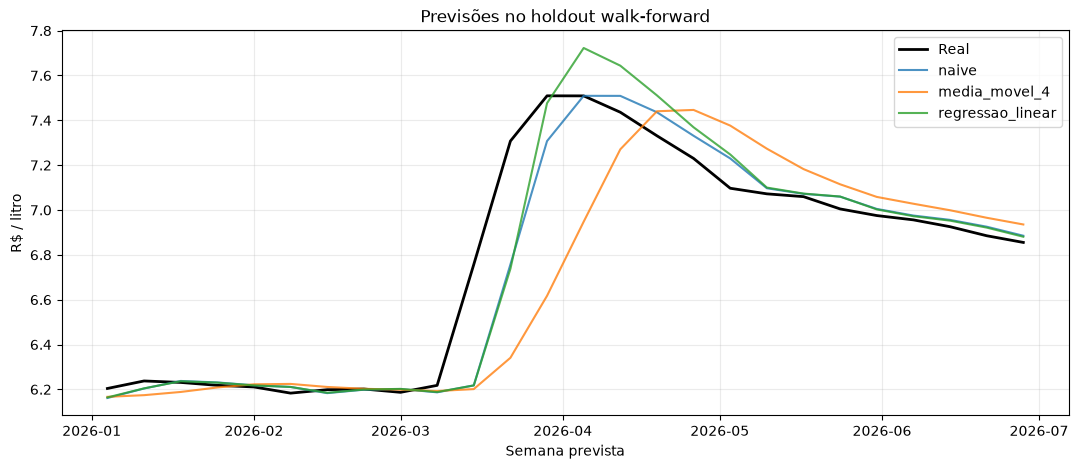

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(predictions['semana_alvo'], predictions['preco_real'], label='Real', color='black', linewidth=2)
for label, column in MODEL_COLUMNS.items():
    ax.plot(predictions['semana_alvo'], predictions[column], label=label, alpha=0.8)
ax.set(title='Previsões no holdout walk-forward', xlabel='Semana prevista', ylabel='R$ / litro')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## 5. Erros e semanas mais difíceis

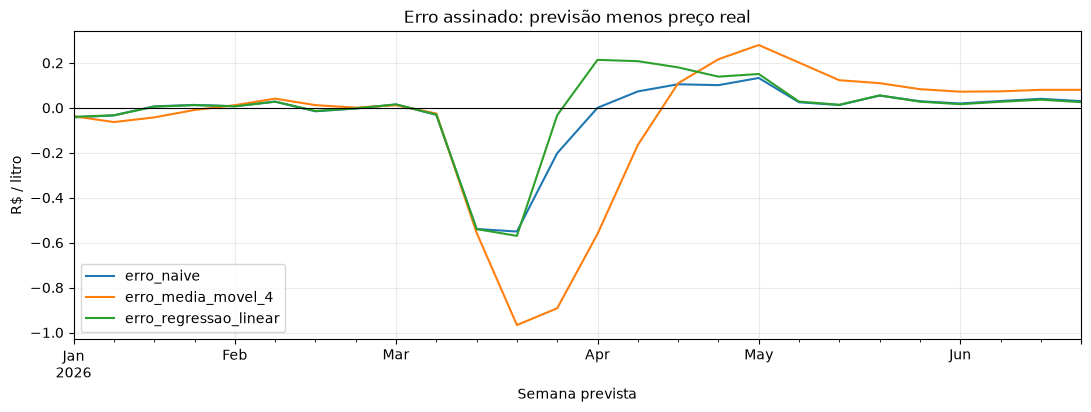

In [7]:
error_columns = [f'erro_{model}' for model in MODEL_COLUMNS]
ax = predictions.plot(
    x='semana_alvo', y=error_columns, figsize=(13, 4),
    title='Erro assinado: previsão menos preço real'
)
ax.axhline(0, color='black', linewidth=0.8)
ax.set(xlabel='Semana prevista', ylabel='R$ / litro')
ax.grid(alpha=0.25)
plt.show()

In [8]:
predictions.nlargest(8, 'erro_abs_naive')[[
    'semana_alvo', 'preco_t', 'preco_real',
    'pred_naive', 'pred_media_movel_4', 'pred_regressao_linear',
    'erro_abs_naive',
]]

,semana_alvo,preco_t,preco_real,pred_naive,pred_media_movel_4,pred_regressao_linear,erro_abs_naive
11,2026-03-22,6.756968,7.307500,6.756968,6.340728,6.737642,0.550532
10,2026-03-15,6.217725,6.756968,6.217725,6.201104,6.217354,0.539243
12,2026-03-29,7.307500,7.509315,7.307500,6.617222,7.476649,0.201815
17,2026-05-03,7.230000,7.097018,7.230000,7.376546,7.247696,0.132982
15,2026-04-19,7.436054,7.331048,7.436054,7.440488,7.511194,0.105006
16,2026-04-26,7.331048,7.230000,7.331048,7.446375,7.368857,0.101048
14,2026-04-12,7.509083,7.436054,7.509083,7.270716,7.643787,0.073029
20,2026-05-24,7.059583,7.004780,7.059583,7.114672,7.060010,0.054803


## 6. Salvar resultados

Execute após conferir as métricas e os gráficos.

In [9]:
output_paths = save_baseline_results(
    predictions, metrics, PROJECT_ROOT / 'processed' / 'baseline'
)
output_paths

{'previsoes': WindowsPath('C:/Users/Wesley.Barbaro/Documents/dados/processed/baseline/baseline_previsoes_walk_forward.csv'),
 'metricas': WindowsPath('C:/Users/Wesley.Barbaro/Documents/dados/processed/baseline/baseline_metricas.csv'),
 'resumo': WindowsPath('C:/Users/Wesley.Barbaro/Documents/dados/processed/baseline/baseline_resumo.json')}

## Próxima decisão

O Naive passa a ser a referência mínima oficial. Em seguida, processaremos dólar e Brent e repetiremos a mesma avaliação para verificar se variáveis externas geram ganho fora da amostra.